# Emotion Recognition using CNN with Attention

This notebook implements a facial emotion recognition system using a Convolutional Neural Network (CNN) enhanced with a spatial attention mechanism. The model classifies grayscale facial images (48×48) into 7 emotion categories.

**Pipeline:**
1. Exploratory Data Analysis (EDA)
2. Data Loading & Augmentation
3. Model Architecture
4. Training
5. Evaluation

## 1. Imports

In [34]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import ImageZ
from collections import Counter
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Exploratory Data Analysis (EDA)

### 2.1 Class Distribution

In [23]:
DATA_DIR = "data"  # Change this path if needed

splits = ["train", "validation", "test"]
class_names = sorted(os.listdir(os.path.join(DATA_DIR, "train")))

print(f"Classes ({len(class_names)}): {class_names}")

Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


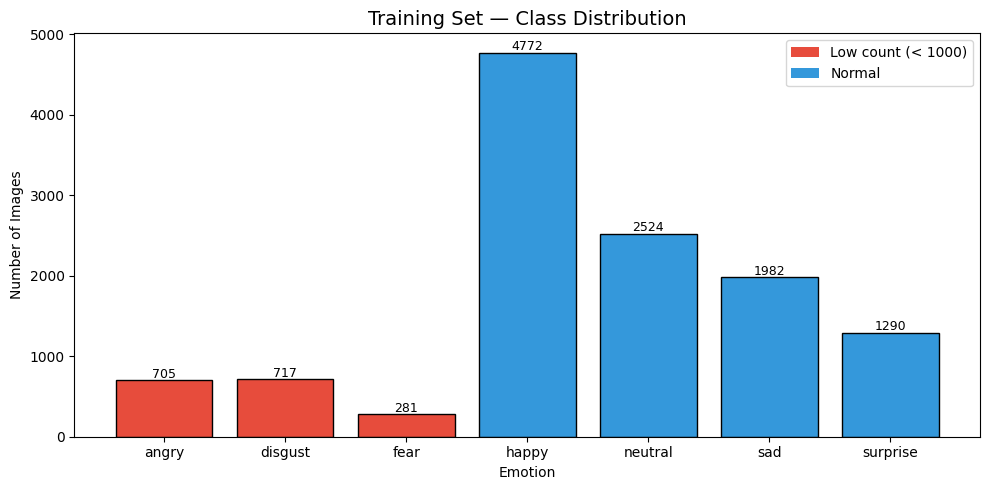


⚠ Low-count classes in training set:
  - angry: 705 images
  - disgust: 717 images
  - fear: 281 images


In [24]:
# Count images per class per split
counts = {}
for split in splits:
    counts[split] = {}
    for cls in class_names:
        path = os.path.join(DATA_DIR, split, cls)
        counts[split][cls] = len(os.listdir(path)) if os.path.isdir(path) else 0

# Bar chart — class distribution in training set
train_counts = counts["train"]
colors = ["#e74c3c" if v < 1000 else "#3498db" for v in train_counts.values()]

plt.figure(figsize=(10, 5))
bars = plt.bar(train_counts.keys(), train_counts.values(), color=colors, edgecolor="black")
plt.title("Training Set — Class Distribution", fontsize=14)
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
for bar, val in zip(bars, train_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, str(val),
             ha="center", fontsize=9)
plt.legend([plt.Rectangle((0,0),1,1,fc="#e74c3c"), plt.Rectangle((0,0),1,1,fc="#3498db")],
           ["Low count (< 1000)", "Normal"], loc="upper right")
plt.tight_layout()
plt.show()

# Print low-count classes
print("\n⚠ Low-count classes in training set:")
for cls, cnt in train_counts.items():
    if cnt < 1000:
        print(f"  - {cls}: {cnt} images")

### 2.2 Split Sizes Comparison

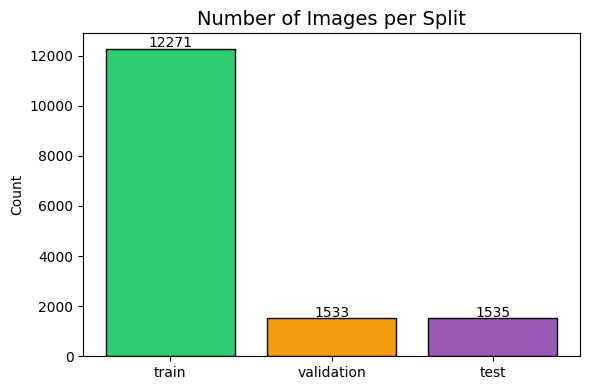

In [25]:
split_totals = {s: sum(counts[s].values()) for s in splits}

plt.figure(figsize=(6, 4))
plt.bar(split_totals.keys(), split_totals.values(), color=["#2ecc71", "#f39c12", "#9b59b6"], edgecolor="black")
plt.title("Number of Images per Split", fontsize=14)
plt.ylabel("Count")
for i, (s, v) in enumerate(split_totals.items()):
    plt.text(i, v + 50, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

### 2.3 Per-Class Distribution Across Splits

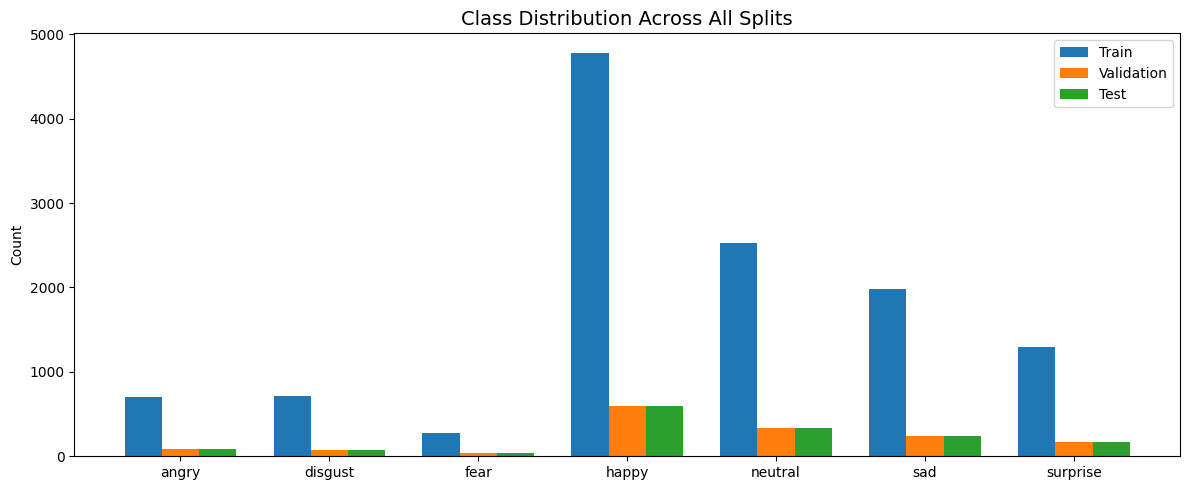

In [26]:
x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, split in enumerate(splits):
    vals = [counts[split][c] for c in class_names]
    ax.bar(x + i * width, vals, width, label=split.capitalize())

ax.set_xticks(x + width)
ax.set_xticklabels(class_names)
ax.set_title("Class Distribution Across All Splits", fontsize=14)
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Random Image Samples

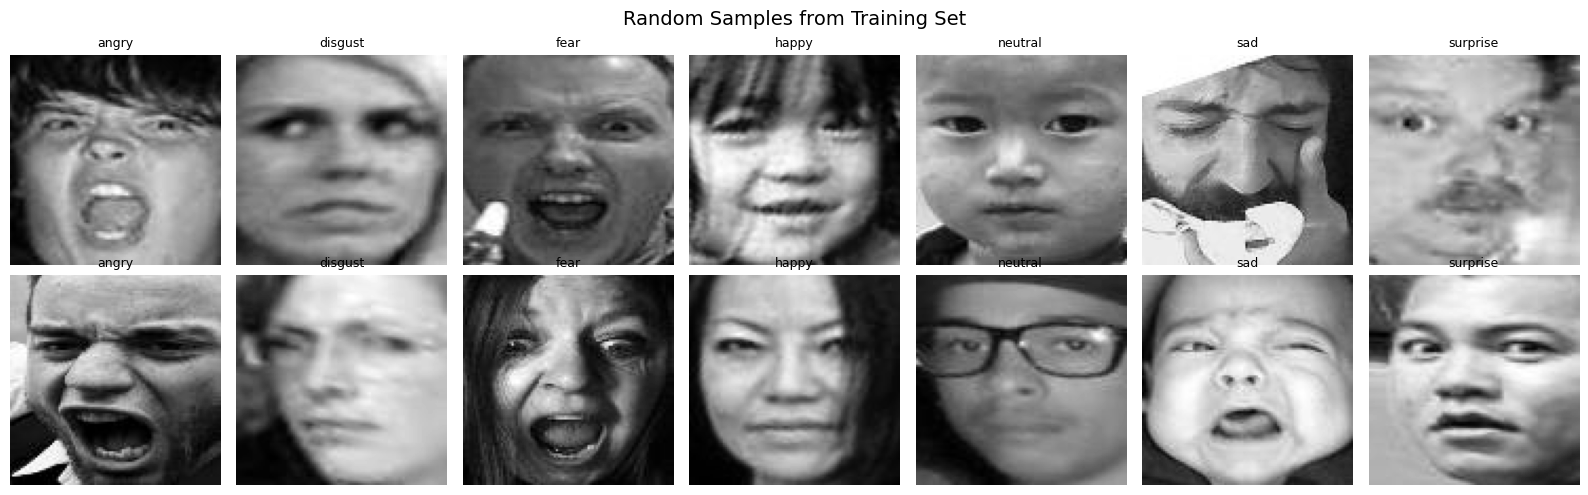

In [27]:
fig, axes = plt.subplots(2, 7, figsize=(16, 5))
fig.suptitle("Random Samples from Training Set", fontsize=14)

for row in range(2):
    for col, cls in enumerate(class_names):
        cls_dir = os.path.join(DATA_DIR, "train", cls)
        img_name = random.choice(os.listdir(cls_dir))
        img = Image.open(os.path.join(cls_dir, img_name)).convert("L")

        axes[row][col].imshow(img, cmap="gray")
        axes[row][col].set_title(cls, fontsize=9)
        axes[row][col].axis("off")

plt.tight_layout()
plt.show()

## 3. Data Loading & Augmentation

In [28]:
def get_loaders(bs=32):
    t_train = transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((48, 48)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomAffine(0, shear=15, scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    t_test = transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train = datasets.ImageFolder(os.path.join(DATA_DIR, "train"),      transform=t_train)
    val   = datasets.ImageFolder(os.path.join(DATA_DIR, "validation"), transform=t_test)
    test  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),       transform=t_test)

    return (
        DataLoader(train, bs, shuffle=True),
        DataLoader(val,   bs, shuffle=False),
        DataLoader(test,  bs, shuffle=False)
    )

BATCH_SIZE = 64
train_loader, val_loader, test_loader = get_loaders(BATCH_SIZE)

# Quick check
x_sample, y_sample = next(iter(train_loader))
print(f"Batch shape: {x_sample.shape}  |  Labels shape: {y_sample.shape}")

Batch shape: torch.Size([64, 1, 48, 48])  |  Labels shape: torch.Size([64])


## 4. Model Architecture

CNN with 3 convolutional blocks (each with 2 conv layers + BatchNorm + ReLU + MaxPool), followed by a spatial attention module and fully connected layers.

In [29]:
class Attention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.attn(x)


class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.conv1   = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1     = nn.BatchNorm2d(32)
        self.conv1_2 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn1_2   = nn.BatchNorm2d(32)

        self.conv2   = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2     = nn.BatchNorm2d(64)
        self.conv2_2 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn2_2   = nn.BatchNorm2d(64)

        self.conv3   = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3     = nn.BatchNorm2d(128)
        self.conv3_2 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn3_2   = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.attn = Attention(128)

        self.fc1  = nn.Linear(128 * 6 * 6, 256)
        self.drop = nn.Dropout(0.6)
        self.fc2  = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool(x)  # 48 -> 24

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool(x)  # 24 -> 12

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn3_2(self.conv3_2(x)))
        x = self.pool(x)  # 12 -> 6

        x = self.attn(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


model = EmotionCNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

EmotionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1_2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2_2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3_2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, tr

## 5. Training

In [30]:
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            total   += y.size(0)
            correct += (preds == y).sum().item()
    return 100 * correct / total

In [31]:
EPOCHS    = 40
LR        = 0.0003
PATIENCE  = 8

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"loss": [], "val_acc": []}
best_acc = 0
counter  = 0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(x), y)

        if torch.isnan(loss):
            print("NaN loss detected — stopping.")
            break

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    val_acc = evaluate(model, val_loader)
    history["loss"].append(total_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {total_loss:.1f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1

    if counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest Validation Accuracy: {best_acc:.2f}%")

Epoch 01/40 | Loss: 306.1 | Val Acc: 58.84%
Epoch 02/40 | Loss: 265.6 | Val Acc: 64.84%
Epoch 03/40 | Loss: 249.4 | Val Acc: 67.19%
Epoch 04/40 | Loss: 240.6 | Val Acc: 71.43%
Epoch 05/40 | Loss: 234.6 | Val Acc: 72.99%
Epoch 06/40 | Loss: 226.8 | Val Acc: 73.78%
Epoch 07/40 | Loss: 222.5 | Val Acc: 73.45%
Epoch 08/40 | Loss: 219.9 | Val Acc: 76.45%
Epoch 09/40 | Loss: 216.7 | Val Acc: 75.54%
Epoch 10/40 | Loss: 214.3 | Val Acc: 75.86%
Epoch 11/40 | Loss: 211.9 | Val Acc: 77.23%
Epoch 12/40 | Loss: 208.9 | Val Acc: 73.32%
Epoch 13/40 | Loss: 206.4 | Val Acc: 76.78%
Epoch 14/40 | Loss: 203.6 | Val Acc: 78.80%
Epoch 15/40 | Loss: 201.5 | Val Acc: 78.67%
Epoch 16/40 | Loss: 200.0 | Val Acc: 80.23%
Epoch 17/40 | Loss: 198.8 | Val Acc: 79.65%
Epoch 18/40 | Loss: 195.6 | Val Acc: 80.23%
Epoch 19/40 | Loss: 194.4 | Val Acc: 79.13%
Epoch 20/40 | Loss: 193.3 | Val Acc: 81.34%
Epoch 21/40 | Loss: 190.8 | Val Acc: 80.63%
Epoch 22/40 | Loss: 189.3 | Val Acc: 80.69%
Epoch 23/40 | Loss: 188.5 | Val 

### 5.1 Training Curves

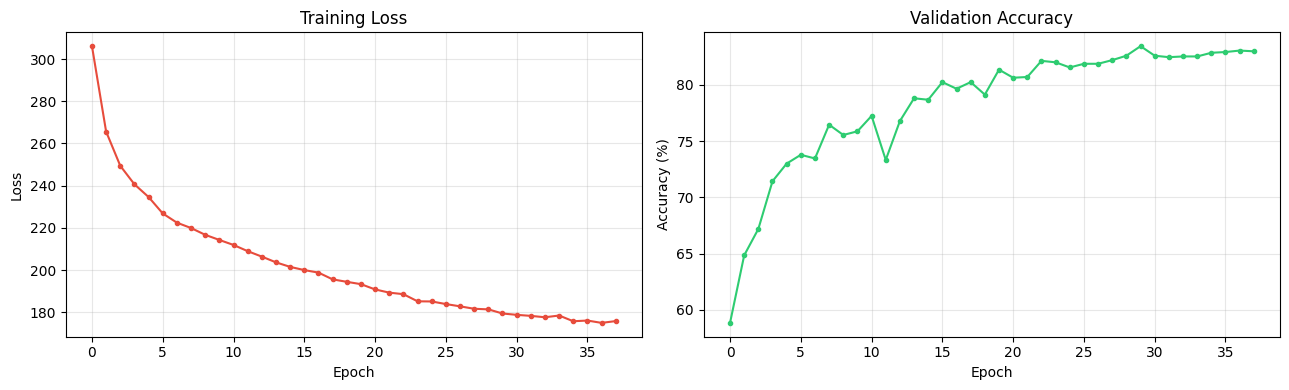

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history["loss"], marker="o", markersize=3, color="#e74c3c")
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(history["val_acc"], marker="o", markersize=3, color="#2ecc71")
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation

In [36]:
# Load best model
model.load_state_dict(torch.load("best_model.pth", weights_only=True))
model.eval()

val_acc  = evaluate(model, val_loader)
test_acc = evaluate(model, test_loader)

print(f"Validation Accuracy : {val_acc:.2f}%")
print(f"Test Accuracy       : {test_acc:.2f}%")

Validation Accuracy : 83.43%
Test Accuracy       : 81.56%



Classification Report:

              precision    recall  f1-score   support

       angry       0.70      0.74      0.72        81
     disgust       0.55      0.36      0.44        80
        fear       0.83      0.14      0.23        37
       happy       0.89      0.93      0.91       593
     neutral       0.79      0.82      0.81       340
         sad       0.76      0.80      0.78       239
    surprise       0.82      0.81      0.82       165

    accuracy                           0.82      1535
   macro avg       0.76      0.66      0.67      1535
weighted avg       0.81      0.82      0.81      1535



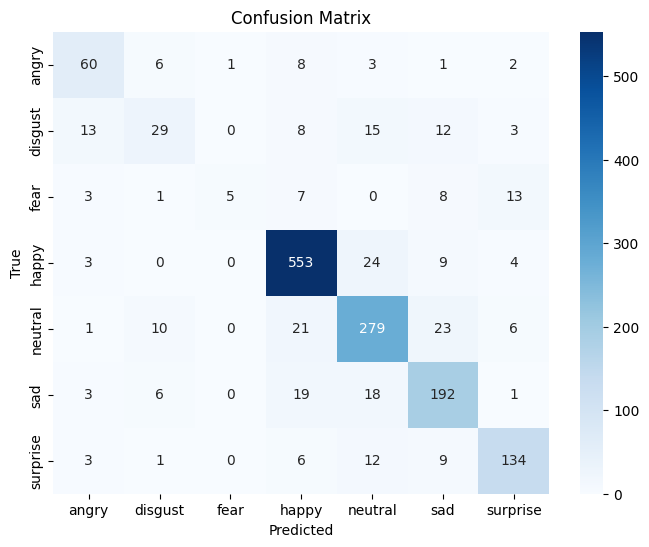

In [37]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())


class_names = test_dataset.classes


# =========================
# Classification Report
# =========================

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)


# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()